In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "notebooks" else HERE
for path in (PROJECT_ROOT / "src", PROJECT_ROOT.parent):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_region_labels(df_eddies, grid)
df_eddies.head()

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,29.449052,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,29.449052,7.225911,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,32.090160,7.712683,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,34.827275,8.275696,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,19.823350,87.507772,D1
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,37.564389,8.838709,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,15.055658,105.302388,D1


In [9]:
def vort_eddy(df, grid):
    df = df.copy()

    df = tilt.add_pv_gradient_terms(df, grid, core_mean=True)
    
    # Calculate total vorticity and PV
    
    # # Normalised PV makes conservation particularly easy to see
    # df['PV_norm'] = df['PV'] / df['PV'].iloc[0]
    
    fig = plt.figure(figsize=(11, 8), constrained_layout=True)
    gs = fig.add_gridspec(
        4, 2,
        width_ratios=[2, 1.3]
    )
    
    axs = [fig.add_subplot(gs[i, 0]) for i in range(4)]
    ax_traj = fig.add_subplot(gs[:, 1])
    
    # --------------------------------------------------
    # Time series
    # --------------------------------------------------
    
    # Depth
    axs[0].plot(df.Day, df.h, 'o-', ms=3)
    axs[0].set_ylabel(r'$h$ (m)')
    axs[0].set_title('Eddy PV evolution')
    
    # Planetary + relative vorticity
    axs[1].plot(df.Day, df.PV_grad_topo_mag, label=r'$f$')
    axs[1].set_ylabel(r'PV grad mag topo (s$^{-1}$)')
    axs[1].legend(frameon=False)
    
    # PV
    df['slope'] = np.hypot(df['dhdx'], df['dhdy'])
    axs[2].plot(df.Day, df.slope, 'o-', ms=3)
    axs[2].set_ylabel('slope')
    axs[2].legend(frameon=False)
    
    # Normalised PV
    axs[3].plot(df.Day, df.TiltDis, 'o-', ms=3)
    axs[3].axhline(1, ls='--', color='k', lw=1)
    axs[3].set_ylabel(r'TiltDis')
    axs[3].set_xlabel('Day')
    
    # Same x range for all time series
    for ax in axs:
        ax.grid(alpha=0.2)
    
    # --------------------------------------------------
    # Eddy trajectory
    # --------------------------------------------------
    
    sc = ax_traj.scatter(
        df.lon,
        df.lat,
        c=df.Day,
        cmap='viridis',
        s=30,
        zorder=3
    )
    
    ax_traj.plot(
        df.lon,
        df.lat,
        color='0.5',
        lw=1,
        zorder=2
    )
    
    # Mark start/end
    ax_traj.scatter(
        df.lon.iloc[0], df.lat.iloc[0],
        marker='o', s=100,
        facecolor='none', edgecolor='k',
        label='Start'
    )
    
    ax_traj.scatter(
        df.lon.iloc[-1], df.lat.iloc[-1],
        marker='x', s=100,
        color='k',
        label='End'
    )

    xlim, ylim = ax_traj.get_xlim(), ax_traj.get_ylim()
    ax_traj.contourf(grid.lon_rho, grid.lat_rho,
                     np.where(grid.mask_rho, grid.h, np.nan),
                     cmap='Grays_r', zorder=-1)
    ax_traj.set_xlim(xlim); ax_traj.set_ylim(ylim)
    
    ax_traj.set_xlabel('Longitude')
    ax_traj.set_ylabel('Latitude')
    ax_traj.set_title('Eddy trajectory')
    ax_traj.legend(frameon=False)
    
    cbar = fig.colorbar(sc, ax=ax_traj, pad=0.02)
    cbar.set_label('Day')
    
    plt.show()
    
    pv_change = 100 * (df.PV.iloc[-1] - df.PV.iloc[0]) / abs(df.PV.iloc[0])
    
    pv_cv = 100 * df.PV.std() / abs(df.PV.mean())
    
    print(f'PV change over lifetime: {pv_change:.2f}%')
    print(f'PV coefficient of variation: {pv_cv:.2f}%')

/scratch/pbs.9115316.kman.restech.unsw.edu.au/ipykernel_2373839/3130601428.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(frameon=False)


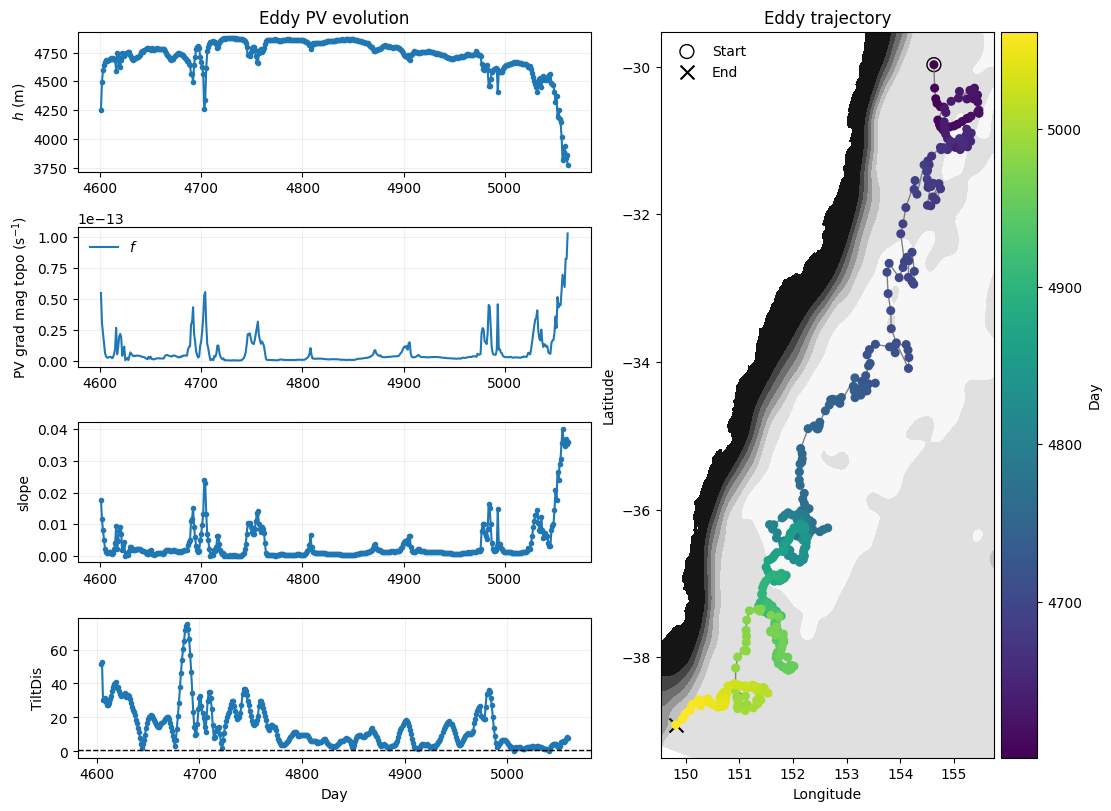

PV change over lifetime: 17.83%
PV coefficient of variation: 17.36%


In [10]:
old_eddy = [int(df_eddies[df_eddies.Age==df_eddies.Age.max()].Eddy.iloc[0])]
df_old = df_eddies[df_eddies.Eddy==old_eddy[0]].copy()
vort_eddy(df_old.copy(), grid)


/scratch/pbs.9115316.kman.restech.unsw.edu.au/ipykernel_2373839/3130601428.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(frameon=False)


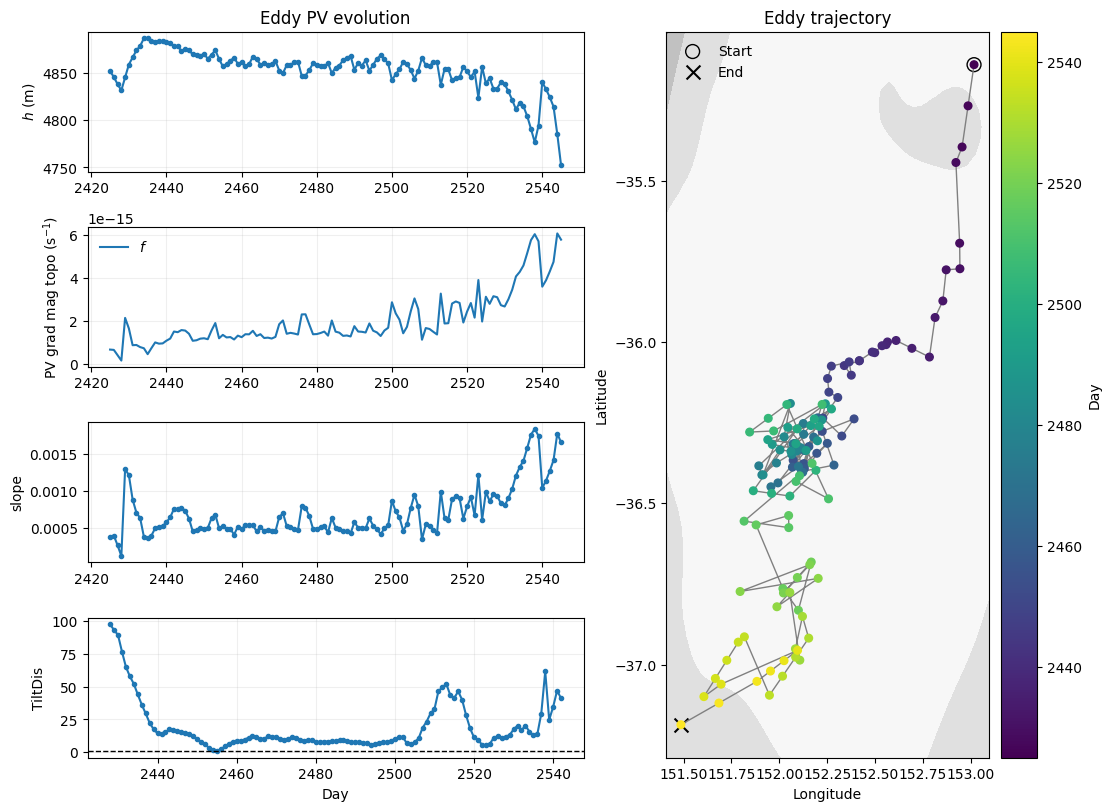

PV change over lifetime: -93.61%
PV coefficient of variation: 20.72%


In [11]:
vort_eddy(df_eddies[df_eddies.Eddy==324].copy(), grid)

/scratch/pbs.9115316.kman.restech.unsw.edu.au/ipykernel_2373839/3130601428.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend(frameon=False)


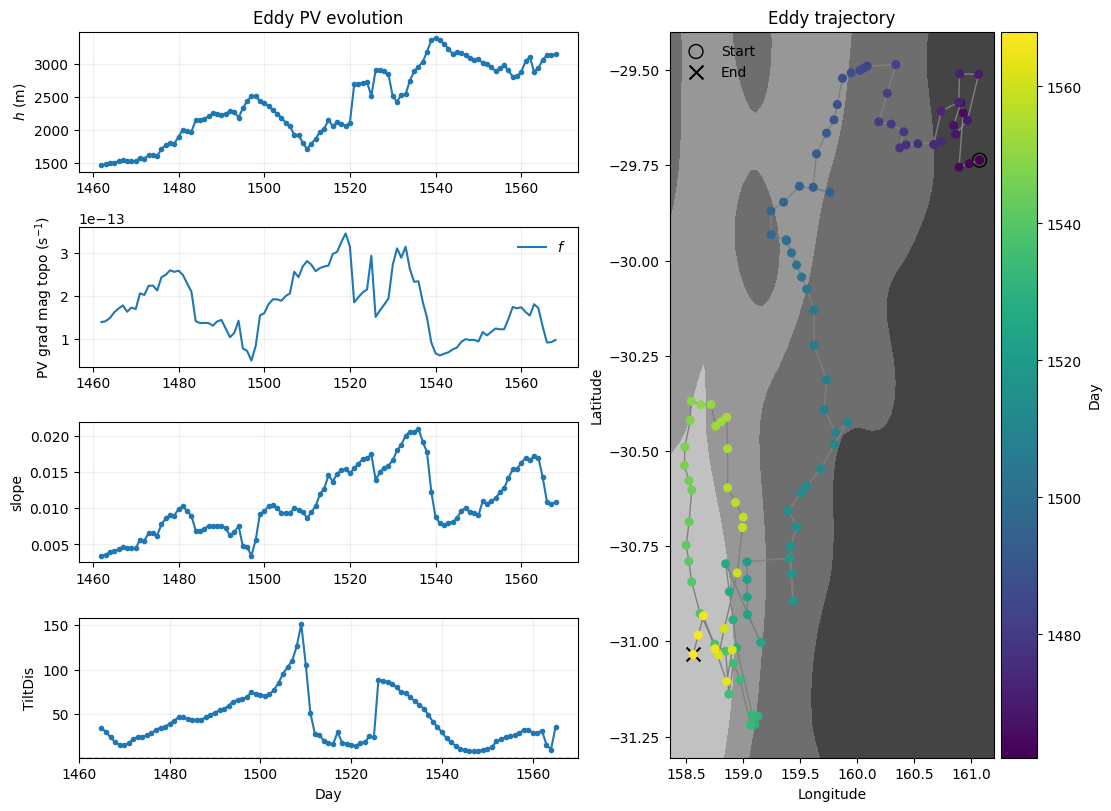

PV change over lifetime: 52.66%
PV coefficient of variation: 24.81%


In [12]:
vort_eddy(df_eddies[df_eddies.Eddy==13].copy(), grid)